In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [7]:
data = pd.read_csv("melbo_clean.csv")

In [8]:
type_order = pd.CategoricalDtype(
    categories=["u", "t", "h"], ordered=True)

data["Type_ord"] = data["Type"].astype(type_order).cat.codes

In [9]:
data = pd.get_dummies(data, columns=["Type"],  prefix=["Type"], drop_first=True)
data = pd.get_dummies(data, columns=["Method"],  prefix=["Method"], drop_first=True)


# slide 115: onehot encoding replaces a categorical column with binary columns,
# one for each category. each row gets a 1 in the column matching its category and 0 in all others.
# this avoids artificial ordering that would mislead the model (slide 112).
# We also use drop_first=True to avoid the dummy variable trap (slide 117).

def encode_features(df):
    df = df.copy()
    df = pd.get_dummies(df, columns=['Type'], prefix='Type', drop_first=True)
    df = pd.get_dummies(df, columns=['Method'], prefix='Method', drop_first=True)
    region_order = pd.CategoricalDtype(
        categories=[
            'Western Victoria', 'Northern Victoria', 'Eastern Victoria',
            'Western Metropolitan', 'Northern Metropolitan',
            'South-Eastern Metropolitan', 'Eastern Metropolitan',
            'Southern Metropolitan'
        ], ordered=True
    )
    df['Regionname_ord'] = df['Regionname'].astype(region_order).cat.codes
    return df

#Function version

In [10]:

from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()
data[["Price_Scaled","Landsize_scaled"]] = std_scaler.fit_transform(data[["Price","Landsize"]])

  # slide 123: standardscaler makes all numerical columns use the same scale.
# without this, a column like Price, in hundreds of thousands, would dominate
# over a column like landsize just because its numbers are bigger, not because
# it is more important. standardscaler fixes this by making every column
# have a mean of 0 and standard deviation of 1.

def scale_features(df):
    df = df.copy()
    scaler = StandardScaler()
    df[['Price_scaled', 'Landsize_scaled']] = scaler.fit_transform(df[['Price', 'Landsize']])
    return df
#Function version

In [11]:
data["bedroom_x_bathroom"] = data["Bedroom2"] * data["Bathroom"].replace(0, np.nan)
data["price_per_room"] = data["Price"] / data["Rooms"].replace(0, np.nan)
data["price_per_bathroom"] = data["Price"] / data["Bathroom"].replace(0, np.nan)
# slide 155: an interaction feature is created by multiplying two columns together.
# the slides say the model cannot figure out the combined effect of two columns on its own,
# so we create it manually. a house with more bedrooms AND more bathrooms together
# is more valuable than either number alone suggests.
#https://www.dummies.com/article/technology/programming-web-design/python/data-science-how-to-create-interactions-between-variables-with-python-142109/

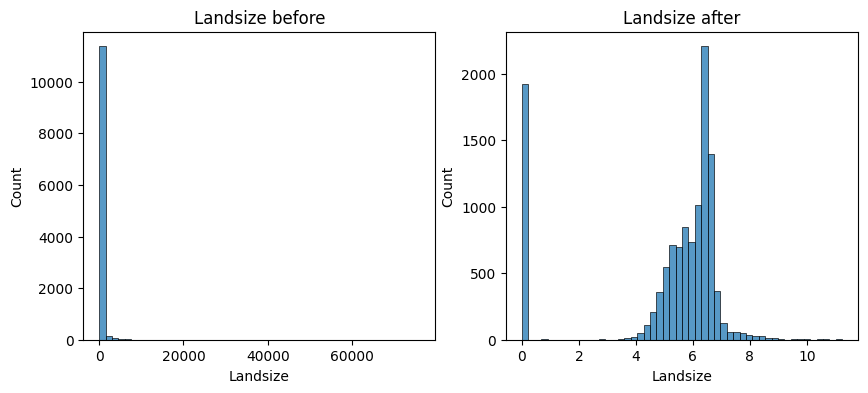

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(data["Landsize"],ax=axes[0],bins=50)
axes[0].set_title("Landsize before")
sns.histplot(np.log1p(data["Landsize"]),ax= axes[1],bins=50)
axes[1].set_title("Landsize after")
plt.show()

data["Landsize_log1p"] = np.log1p(data["Landsize"])
# slide 134 says np.log1p is used to fix a skewed column by compressing very large values
# so they do not have too much influence on the model. i used Landsize because we already
# confirmed it is skewed earlier when the mean was much higher than the median.
# The histograms show the distribution before and after the transform so we can visually
# confirm the skew has been reduced.  also used https://www.statology.org/transform-data-in-python/ to help me better understand
# why log transformation is used on skewed data and how to visualize the before and after.


# As we can see, the before histogram is heavily skewed to the right with most values bunched
# on the left, and the after histogram shows a more centered distribution after the log transform.

# I also used bins = 50 to make it easier to look at, it looked wonky before

In [13]:
def bin_features(df):
    df = df.copy()
    bin_edges = [0, 2, 4, 100]
    bin_labels = ['Small', 'Medium', 'Large']
    df['Rooms_binned'] = pd.cut(df['Rooms'], bins=bin_edges, labels=bin_labels, right=False)
    return df

    # slides 129 and 131: instead of using the exact number of rooms, we group them into 3 categories.
# this is called binning. a property with 1-2 rooms is small, 3-4 rooms is medium,
# and 5 or more rooms is large. the slides say bins should reflect how people
# actually think about the data, and buyers naturally think in terms of
# small, medium and large properties rather than exact room counts.
# we use pd.cut to split the Rooms column into these three groups.
# https://saturncloud.io/blog/binning-a-column-with-python-pandas/


In [14]:

def drop_correlated(df, threshold=0.95):
    df = df.copy()
    numeric_data = df.select_dtypes(include='number')
    corr_matrix = numeric_data.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    return df.drop(columns=to_drop), to_drop
    # slides 171 and 172: When two columns contain almost the same information, one of them is redundant
# and can be removed. This is called multicollinearity and it confuses the model because
# it sees the same pattern twice. we use a correlation matrix to find pairs of columns
# that are more than 95% similar to each other. for any pair above this threshold,
# we drop one column since the other already contains the same information.
# This makes the model simpler and more stable.

In [15]:
# save cleaned data so we can load it in the EDA notebook
data.to_csv('melbourne_cleanv2.csv', index=False)